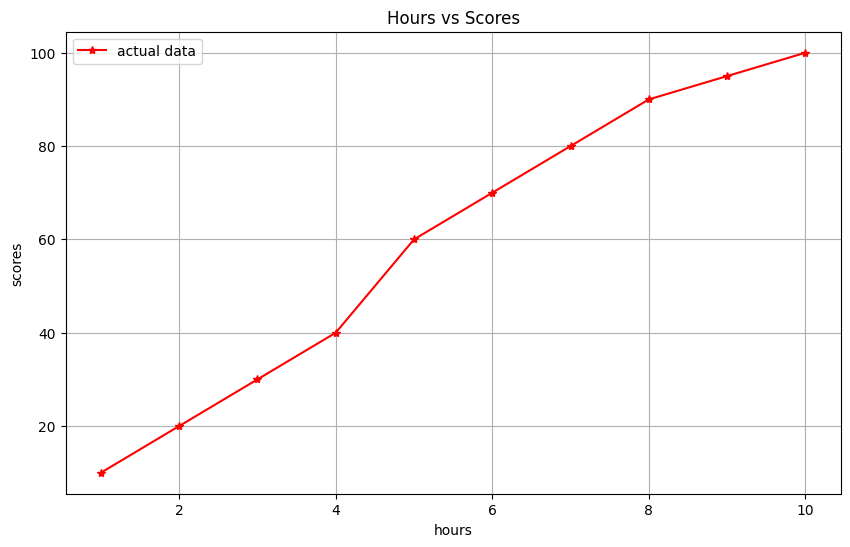

best fit line equation:
score =10*hours+50

for 7 hours -predicted score: 8.17


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

hours=np.array([1,2,3,4,5,6,7,8,9,10])
scores=np.array([10,20,30,40,60,70,80,90,95,100])
predicted_score=11.94+-3.77
plt.figure(figsize=(10,6))
plt.plot(hours,scores,label='actual data',color="red",marker="*")
plt.xlabel("hours")
plt.ylabel("scores")
plt.title("Hours vs Scores")
plt.legend()
plt.grid(True)
plt.show()
print("best fit line equation:")
print("score =10*hours+50")
print("\nfor 7 hours -predicted score:",predicted_score)

In [ ]:
import numpy as np

x=np.array([1,2,3,4,5],dtype=float)
y=np.array([10,20,30,40,60],dtype=float)

m=0
c=0

learning_rate=0.01

epochs=1000

n=len(x)

for i in range(epochs):
  y_pred=m*x+c
  error=y-y_pred
  mse=np.mean(error ** 2)

  dm=(-2/n)*np.sum(x*error)
  dc=(-2/n)*np.sum(error)


  m=m-learning_rate*dm
  c=c-learning_rate*dc

if i % 100 == 0:
  print(f"epoch{i}")
  print(f"MSE={mse:.2f}")
  print('m = {m:.2f},c={c:.2f}')
  print("----------------")


#final equation
print("\n Final Best FIt Line:")
print(f'y={m:.2f}x+{c:.2f}')


 Final Best FIt Line:
y=11.94x+-3.77


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

experience=np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
salary=np.array([10,15,20,25,30,40,60,65,70,75,80,85,90,95,100])
x=experience.reshape(-1,1)
y=salary

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

print(f"Training samples:{len(x_train)}")
print(f"Testing samples:{len(x_test)}")

Training samples:12
Testing samples:3


## Fitting and Predicting

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print(f"slope={model.coef_[0]:.2f}")
print(f"Intercept:{model.intercept_:.2f}")
y_pred=model.predict(x_test)
for actual,predicted in zip(y_test,y_pred):
  print(f"actual={actual:>15} predicted = {predicted:>7.2f}",f"Error {predicted - actual:>+.1f}")

slope=6.85
Intercept:2.43
actual=             25 predicted =   29.84 Error +4.8
actual=             65 predicted =   57.24 Error -7.8
actual=             90 predicted =   91.49 Error +1.5


# calculating all three metrics

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

y_actual=np.array([500,600,300,200,350])
y_pred=np.array([15,25,45,50,60])

r2=r2_score(y_actual,y_pred)
mae=mean_absolute_error(y_actual,y_pred)
mse=np.sqrt(mean_squared_error(y_actual,y_pred))
r2_100 =r2*100

print(f"r2 Score:{r2:.5f}-> model explains{r2_100:.1f}% of variance")
print(f"Mean Absolute Error:{mae:.2f} -> avg error_+:{mae:.1f} units")
print(f"Mean Squared Error:{mse:.2f}-> penalised avg error{mse:.0f} units")


r2 Score:-6.23015-> model explains-623.0% of variance
Mean Absolute Error:351.00 -> avg error_+:351.0 units
Mean Squared Error:384.05-> penalised avg error384 units


Multiple Features

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
# Create a realistic salary dataset
np.random.seed(42)
n = 100
data = pd.DataFrame({
 'experience': np.random.randint(0, 20, n), # 0–20 years
 'education': np.random.randint(12, 20, n), # 12–20 years schooling
 'age': np.random.randint(22, 55, n), # 22–55 years
})

data['salary']=(
    data['experience']*4500+
    data['education']*2000+
    data['age']*300+
    np.random.normal(0,3000,n)+10000
)

x=data[['experience','education','age']]
y=data['salary']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=145000)
model = LinearRegression()
model.fit(x_train,y_train)

for feat,coef in zip(x.columns,model.coef_):
  print(f"{feat:12s}:s{coef:.0f}per unit increase")
  print(f"Base salary (Intercept):${model.intercept_:.0f}")

y_pred=model.predict(x_test)
print(f"\r2 Score:{r2_score(y_test,y_pred):.2f}")
print(f"MAE :$(mean_absolute_error(y_test,y_pred):.0f)")




experience  :s4517per unit increase
Base salary (Intercept):$8597
education   :s2153per unit increase
Base salary (Intercept):$8597
age         :s269per unit increase
Base salary (Intercept):$8597
2 Score:0.98
MAE :$(mean_absolute_error(y_test,y_pred):.0f)


# LAB

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
np.random.seed(42)
n = 200
locations = ['Urban', 'Suburban', 'Rural']
df = pd.DataFrame({
 'area_sqft': np.random.randint(500, 4000, n),
 'num_rooms': np.random.randint(1, 7, n),
 'location': np.random.choice(locations, n),
 'age_years': np.random.randint(0, 40, n),
})
# Location multipliers
loc_map = {'Urban': 1.5, 'Suburban': 1.0, 'Rural': 0.7}#expensiv medium cheap
noise = np.random.normal(0, 20000, n)
df['price'] = (
 df['area_sqft'] * 150 +
 df['num_rooms'] * 25000 -
 df['age_years'] * 2000 +
 df['location'].map(loc_map) * 50000 +
 noise
).astype(int)
print(df.head(8).to_string(index=False))
print(f"\nDataset shape : {df.shape}")
print(df.describe()[['area_sqft','num_rooms','age_years','price']].round(0))

 area_sqft  num_rooms location  age_years  price
      3674          4    Rural         20 646067
      1360          4    Urban         35 300479
      1794          6    Urban          9 501609
      1630          6    Rural         36 355668
      1595          3    Urban          8 391991
      3592          2    Rural         23 566413
      2138          4 Suburban         34 410974
      2669          1    Urban         34 459191

Dataset shape : (200, 5)
       area_sqft  num_rooms  age_years     price
count      200.0      200.0      200.0     200.0
mean      2334.0        3.0       20.0  451548.0
std        992.0        2.0       11.0  154871.0
min        521.0        1.0        0.0   86373.0
25%       1519.0        2.0       10.0  326188.0
50%       2372.0        3.0       20.0  458282.0
75%       3230.0        5.0       30.0  575910.0
max       3999.0        6.0       39.0  781261.0


# Step 2 — Encode & Prepare Features

In [ ]:
# Encode location: Urban=2, Suburban=1, Rural=0
#Creates a tool that converts text → numbers
le = LabelEncoder()
#transform Converts them into numbers automatically
df['location_enc'] = le.fit_transform(df['location'])
# Select features and target
features = ['area_sqft', 'num_rooms', 'age_years', 'location_enc']
X = df[features]
y = df['price']
# Peek at encoded data
print(df[['location', 'location_enc']].drop_duplicates().sort_values('location_enc'))
print(f"\nFeature matrix shape : {X.shape}")
print(f"Target vector shape : {y.shape}")

   location  location_enc
0     Rural             0
6  Suburban             1
1     Urban             2

Feature matrix shape : (200, 4)
Target vector shape : (200,)


# Step 3 — Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)
print(f"Training samples : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing samples : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"Feature names : {features}")

Training samples : 160 (80%)
Testing samples : 40 (20%)
Feature names : ['area_sqft', 'num_rooms', 'age_years', 'location_enc']


Step 4 — Train the Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Learned Coefficients:")
print("-" * 45)
for feat, coef in zip(features, model.coef_):
 direction = "↑" if coef > 0 else "↓"
 print(f" {feat:15s}: Rs {coef:>10,.0f} {direction}")
print(f" {'intercept':15s}: Rs {model.intercept_:>10,.0f}")
print("-" * 45)
# Interpretation:
# area_sqft → every extra sq ft adds ~Rs 150 to price
# num_rooms → every extra room adds ~Rs 25,000
# age_years → every year older reduces by ~Rs 2,000

Learned Coefficients:
---------------------------------------------
 area_sqft      : Rs        151 ↑
 num_rooms      : Rs     23,169 ↑
 age_years      : Rs     -2,262 ↓
 location_enc   : Rs     18,114 ↑
 intercept      : Rs     46,789
---------------------------------------------


# Step 5 — Evaluate


In [ ]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("=" * 40)
print(" MODEL EVALUATION REPORT")
print("=" * 40)
print(f"R² Score : {r2:.4f} {'✓ Excellent' if r2>0.9 else '✓ Good' if r2>0.8 else '■ Needs work'}")
print(f"MAE : Rs {mae:>10,.0f}")
print(f"RMSE : Rs {rmse:>10,.0f}")
print("=" * 40)
# Show first 8 predictions vs actuals
print("\nSample Predictions:")
print(f"{'Actual':>10} | {'Predicted':>10} | {'Error':>10}")
print("-" * 36)
for a, p in zip(y_test[:8], y_pred[:8]):
 print(f"{a:>10,} | {p:>10,.0f} | {p-a:>+10,.0f}")

 MODEL EVALUATION REPORT
R² Score : 0.9872 ✓ Excellent
MAE : Rs     13,439
RMSE : Rs     16,959

Sample Predictions:
    Actual |  Predicted |      Error
------------------------------------
   489,899 |    478,320 |    -11,579
   601,329 |    572,877 |    -28,452
   623,788 |    650,489 |    +26,701
   291,458 |    271,086 |    -20,372
   390,040 |    344,431 |    -45,609
   123,884 |    134,545 |    +10,661
   484,442 |    443,295 |    -41,147
   562,823 |    556,350 |     -6,473


## Step 6 — Predict on New Houses


In [ ]:
# New houses to price
new_houses = pd.DataFrame({
 'area_sqft': [1845, 4500, 900, 8900],
 'num_rooms': [5, 3, 2, 5 ],
 'age_years': [6, 20, 35, 4 ],
 'location_enc':[8, 5, 7, 5 ], # 2=Urban,1=Suburban,0=Rural
 'location_lbl':['Urban','Suburban','Rural','Urban'],
})
predictions = model.predict(new_houses[features])
print("\n HOUSE PRICE PREDICTIONS")
print("=" * 60)
for i, (_, row) in enumerate(new_houses.iterrows()):
 print(f" House {i+1}: {row.area_sqft} sqft | "
 f"{row.num_rooms} rooms | "
 f"{row.age_years}yr old | "
 f"{row.location_lbl}")
 print(f" Estimated Price → Rs {predictions[i]:>10,.0f}")
 print()


 HOUSE PRICE PREDICTIONS
 House 1: 1845 sqft | 5 rooms | 6yr old | Urban
 Estimated Price → Rs    571,800

 House 2: 4500 sqft | 3 rooms | 20yr old | Suburban
 Estimated Price → Rs    839,254

 House 3: 900 sqft | 2 rooms | 35yr old | Rural
 Estimated Price → Rs    276,275

 House 4: 8900 sqft | 5 rooms | 4yr old | Urban
 Estimated Price → Rs  1,584,360

